In [1]:
import torch
import torchtext
from torchtext.datasets import text_classification

from torch.utils.data import DataLoader
NGRAMS = 2 # try 3
import os

import numpy as np

In [2]:
MODEL_PATH = './saved_models'
if not os.path.isdir(MODEL_PATH):
    os.mkdir(MODEL_PATH)

if not os.path.isdir('./.data'):
    os.mkdir('./.data')

train_dataset, test_dataset = text_classification.DATASETS['AG_NEWS'](
    root='./.data', ngrams=NGRAMS, vocab=None
)
BATCH_SIZE = 1 # Only works with BATCH_SIZE = 1 for now
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

120000lines [00:07, 16047.45lines/s]
120000lines [00:12, 9469.25lines/s] 
7600lines [00:00, 9414.83lines/s] 


In [3]:
VOCAB_SIZE = len(train_dataset.get_vocab())
EMBED_DIM = 32
NUM_CLASSES = len(train_dataset.get_labels())

In [5]:
# Model Definition
import torch.nn as nn
import torch.nn.functional as F

class TextClassification(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=True)
        self.fc1 = nn.Linear(embed_dim, num_classes)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc1.weight.data.uniform_(-initrange, initrange)
        self.fc1.bias.data.zero_()

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        out = self.fc1(embedded)
        return out

In [6]:
model = TextClassification(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES).to(device)
vocab = train_dataset.get_vocab()

In [7]:
def generate_batch(batch):
    label = torch.tensor([entry[0] for entry in batch])
    text = [entry[1] for entry in batch]
    offsets = [0] + [len(entry) for entry in text]
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text = torch.cat(text)
#     text = text.unsqueeze(0)
    
    return text, offsets, label

In [8]:
def train_func(sub_train_):

    # Training Model
    train_loss = 0
    train_acc = 0
    data = DataLoader(sub_train_, batch_size=BATCH_SIZE, shuffle=True, \
    collate_fn=generate_batch)

    for i, (text, offsets, label) in enumerate(data):
        optimizer.zero_grad()
        text, offsets, label = text.to(device), offsets.to(device), label.to(device)

        output = model(text, offsets)

        loss = criterion(output, label)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        train_acc += (output.argmax(1) == label).sum().item()
    
    scheduler.step()

    return train_loss / len(sub_train_), train_acc / len(sub_train_)

In [9]:
def test(data_):
    loss = 0
    acc = 0
    data = DataLoader(data_, batch_size=BATCH_SIZE, collate_fn=generate_batch)
    for text, offsets, label in data:
        text, offsets, label = text.to(device), offsets.to(device), label.to(device)

        with torch.no_grad():
            output = model(text, offsets)
            loss = criterion(output, label)
            loss += loss.item()
            acc += (output.argmax(1) == label).sum().item()
        
    return loss / len(data_), acc / len(data_)

In [11]:
# Split Dataset and Run Model
import time
from torch.utils.data.dataset import random_split
N_EPOCHS = 10
min_valid_loss = float('inf')

train_losses = []
val_losses = []

criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=4.0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.9)

train_len = int(len(train_dataset) * 0.95)
sub_train_, sub_valid = \
    random_split(train_dataset, [train_len, len(train_dataset) - train_len])
print("Training on {}".format(device))

for epoch in range(N_EPOCHS):

    start_time = time.time()
    train_loss, train_acc = train_func(sub_train_)
    valid_loss, valid_acc = test(sub_valid)
    train_losses.append(train_loss)
    val_losses.append(valid_loss)
    secs = int(time.time() - start_time)
    mins = secs / 60
    secs = secs % 60

    print('Epoch: %d' %(epoch + 1), " | time in %d minutes, %d seconds" %(mins, secs))
    print(f'\tLoss: {train_loss:.4f}(train)\t|\tAcc: {train_acc * 100:.1f}%(train)')
    print(f'\tLoss: {valid_loss:.4f}(valid)\t|\tAcc: {valid_acc * 100:.1f}%(valid)')

torch.save(model, "saved_models/linear_nn.pth")

Training on cuda
Epoch: 1  | time in 4 minutes, 44 seconds
	Loss: 610.9251(train)	|	Acc: 81.7%(train)
	Loss: 0.0000(valid)	|	Acc: 68.7%(valid)
Epoch: 2  | time in 4 minutes, 44 seconds
	Loss: 3128.8405(train)	|	Acc: 84.3%(train)
	Loss: 0.0000(valid)	|	Acc: 80.2%(valid)
Epoch: 3  | time in 4 minutes, 43 seconds
	Loss: 5615.2367(train)	|	Acc: 87.6%(train)
	Loss: 0.0000(valid)	|	Acc: 87.7%(valid)
Epoch: 4  | time in 4 minutes, 42 seconds
	Loss: 5195.2052(train)	|	Acc: 91.0%(train)
	Loss: 0.0000(valid)	|	Acc: 89.0%(valid)
Epoch: 5  | time in 4 minutes, 44 seconds
	Loss: 3704.7952(train)	|	Acc: 93.7%(train)
	Loss: 0.0000(valid)	|	Acc: 89.0%(valid)
Epoch: 6  | time in 4 minutes, 44 seconds
	Loss: 2287.5931(train)	|	Acc: 95.7%(train)
	Loss: 0.0000(valid)	|	Acc: 89.3%(valid)
Epoch: 7  | time in 4 minutes, 41 seconds
	Loss: 1370.6406(train)	|	Acc: 97.1%(train)
	Loss: 0.0000(valid)	|	Acc: 90.6%(valid)
Epoch: 8  | time in 4 minutes, 42 seconds
	Loss: 796.1969(train)	|	Acc: 98.1%(train)
	Loss: 0.0

c:\users\zain\appdata\local\programs\python\python37\lib\site-packages\torch\serialization.py:256: UserWarning: Couldn't retrieve source code for container of type TextClassification. It won't be checked for correctness upon loading.
  "type " + obj.__name__ + ". It won't be checked "


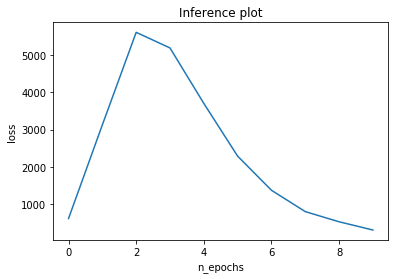

In [41]:
import matplotlib.pyplot as plt
def plot_inference(num_epochs, losses):
    plt.plot(range(num_epochs), losses)
    plt.title('Inference plot')
    plt.xlabel('n_epochs')
    plt.ylabel('loss')
    plt.show()

plot_inference(N_EPOCHS, train_losses)

In [16]:
print('Checking the results of test dataset...')
test_loss, test_acc = test(test_dataset)
print(f'\tLoss: {test_loss:.4f}(test)\t|\tAcc: {test_acc * 100:.1f}%(test)')

Checking the results of test dataset...
	Loss: 0.0000(test)	|	Acc: 91.1%(test)


In [29]:
# Predict
import re
from torchtext.data.utils import ngrams_iterator
from torchtext.data.utils import get_tokenizer

NGRAMS = 2

labels = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

def predict(text, model, vocab, ngrams):
    tokenizer = get_tokenizer("basic_english")
    with torch.no_grad():
        text = torch.tensor([vocab[token] for token in ngrams_iterator(tokenizer(text), ngrams)])
#         text.to(device)
        out = model(text, torch.tensor([0]))
    return out.argmax(1).item() + 1
    
MODEL_PATH = 'saved_models/linear_nn.pth'
model = torch.load(MODEL_PATH)
model.to('cpu')

TextClassification(
  (embedding): EmbeddingBag(1308844, 32, mode=mean)
  (fc1): Linear(in_features=32, out_features=4, bias=True)
)

In [42]:
test_input = "Hundreds of tech workers pack an auditorium for a recent networking event in Toronto. The evening's host glides around the room on a hoverboard, equal parts game show host and tech bro."

In [43]:
prediction = predict(test_input, model, vocab, NGRAMS)
print("News genre: {}".format(labels[prediction]))

News genre: Sci/Tech
